# scVI on Object A (human-only) — best sweep parameters

* **Developed by:** Anna Maguza
* **Affilation:** CellZome, a GSK company
* **Created date:** 2026-05-08
* **Last modified date:** 2026-05-13

Train the final scVI integration for Object A using the hyperparameters picked by `3a1b_scvi_sweep_summary.ipynb`. Reads `sweep_scvi/best_scvi_config.json`; persists `integrated_obj_a_scvi.h5ad` + `model_scvi_obj_a_scvi/` for downstream notebooks (3a2 scANVI, 4_benchmark, 5_comparisons, 8a_headline).

**Kernel: `lgr5_enhanced`.**


In [62]:
import json, datetime as dt
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import scvi
import torch
import matplotlib.pyplot as plt

In [63]:
sc.settings.verbosity = 2
sc.settings.dpi = 120
sc.settings.dpi_save = 300
plt.rcParams.update({
    'savefig.bbox': 'tight', 'savefig.dpi': 300, 'figure.dpi': 120,
    'font.family': ['Arial', 'Helvetica', 'DejaVu Sans'], 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
})

In [64]:
REPO     = Path('/Users/am336941/Library/CloudStorage/OneDrive-GSK/Desktop/Fetal_stem_cells_analysis')
DATA_OUT = Path('/Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced')
INPUT    = DATA_OUT / 'object_a_human.h5ad'
FIG_DIR  = REPO / 'analysis_enhanced/3_integration/3a_human_only/figures/obj_a_scvi'
FIG_DIR.mkdir(parents=True, exist_ok=True)
BEST_JSON = REPO / 'analysis_enhanced/3_integration/3a_human_only/sweep_scvi/best_scvi_config.json'


## 1. Load best-parameter config

Falls back to a hard-coded copy of the winner if `best_scvi_config.json` is missing (so the notebook is still runnable standalone).

In [65]:
HARDCODED_BEST = {
    'n_top_hvgs': 2000, 'n_latent': 30, 'n_hidden': 256, 'n_layers': 2,
    'gene_likelihood': 'nb', 'dropout_rate': 0.1, 'dispersion': 'gene-batch',
    'batch_key': 'Study_name', 'labels_key': 'cell_states',
    'categorical_covariate_keys': ['age_group'],
    'continuous_covariate_keys': [],
    'max_epochs': 200, 'early_stopping': True, 'early_stopping_patience': 10,
    'check_val_every_n_epoch': 1, 'batch_size': 256,
    'min_cells_per_gene': 10, 'hvg_flavor': 'seurat_v3',
    'hvg_batch_key': 'Study_name', 'random_state': 0,
}
if BEST_JSON.exists():
    BEST = json.loads(BEST_JSON.read_text())
    print('loaded', BEST_JSON)
else:
    BEST = HARDCODED_BEST
    print('using HARDCODED_BEST (run 3a1b_scvi_sweep_summary.ipynb to refresh)')
BEST


loaded /Users/am336941/Library/CloudStorage/OneDrive-GSK/Desktop/Fetal_stem_cells_analysis/analysis_enhanced/3_integration/3a_human_only/sweep_scvi/best_scvi_config.json


{'n_top_hvgs': 2000,
 'n_latent': 30,
 'n_hidden': 256,
 'n_layers': 2,
 'gene_likelihood': 'nb',
 'dropout_rate': 0.1,
 'dispersion': 'gene-batch',
 'batch_key': 'Study_name',
 'labels_key': 'cell_states',
 'categorical_covariate_keys': ['age_group', 'sample_id'],
 'continuous_covariate_keys': [],
 'max_epochs': 100,
 'early_stopping': True,
 'early_stopping_patience': 10,
 'check_val_every_n_epoch': 1,
 'batch_size': 256,
 'min_cells_per_gene': 10,
 'hvg_flavor': 'seurat_v3',
 'hvg_batch_key': 'Study_name',
 'random_state': 0,
 '_picked_from_sweep_run': 'cov_age_sample'}

## 2. Load Object A; preprocess (matches sweep pipeline)

In [66]:
adata = sc.read_h5ad(INPUT)
print(adata.shape)

(102460, 20112)


In [67]:
if 'counts' not in adata.layers:
    adata.layers['counts'] = adata.X.copy()

In [68]:
def X_is_raw(a):
    return np.array_equal(a.X.sum(axis=0).astype(int), a.X.sum(axis=0))
print(f'X_is_raw={X_is_raw(adata)}  X_dtype={adata.X.dtype}  layers={list(adata.layers.keys())}')

X_is_raw=True  X_dtype=int64  layers=['counts']


In [69]:
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None, log1p=False)

In [70]:
# show range for total counts per cell
print('total counts per cell:')
print(adata.obs['n_genes_by_counts'].describe())

total counts per cell:
count    102460.000000
mean       1859.298800
std        1416.373592
min          58.000000
25%         616.000000
50%        1587.000000
75%        2752.000000
max        9167.000000
Name: n_genes_by_counts, dtype: float64


In [71]:
adata.shape

(102460, 20112)

In [72]:
adata = adata[adata.obs['n_genes_by_counts'] >= 100].copy()

In [73]:
adata.shape

(102013, 20112)

In [74]:
# Gene filter — identical to the sweep, so the trained model uses the same gene space.
n0 = adata.n_vars
sc.pp.filter_genes(adata, min_cells=BEST['min_cells_per_gene'])
if adata.layers['counts'].shape[1] != adata.n_vars:
    adata.layers['counts'] = adata.X.copy()
print(f'gene filter min_cells={BEST["min_cells_per_gene"]}: {n0} -> {adata.n_vars}')


gene filter min_cells=10: 20112 -> 17555


In [75]:
sc.pp.highly_variable_genes(
    adata, flavor=BEST['hvg_flavor'],
    n_top_genes=BEST['n_top_hvgs'],
    layer='counts',
    batch_key=BEST['hvg_batch_key'],
    subset=True,
)
print('after HVG:', adata.shape)


after HVG: (102013, 2000)


## 3. scVI setup + train

Configuration replicates the winning sweep run (`cov_age_sample`): `batch_key='Study_name'`, `categorical_covariate_keys=['age_group','sample_id']`, no continuous covariates, `n_latent=30`, `n_hidden=256`, `n_layers=2`, `gene_likelihood='nb'`, `dispersion='gene-batch'`, `dropout_rate=0.1`.

In [76]:
scvi.settings.seed = BEST['random_state']
scvi.model.SCVI.setup_anndata(
    adata,
    layer='counts',
    batch_key=BEST['batch_key'],
    labels_key=BEST['labels_key'],
    categorical_covariate_keys=BEST['categorical_covariate_keys'] or None,
    continuous_covariate_keys=BEST['continuous_covariate_keys'] or None,
)

def _accel():
    if torch.cuda.is_available(): return 'cuda'
    if torch.backends.mps.is_available(): return 'mps'
    return 'cpu'
ACCEL = _accel()
print('accelerator:', ACCEL)


Seed set to 0


accelerator: mps


In [77]:
model = scvi.model.SCVI(
    adata,
    n_layers=BEST['n_layers'],
    n_latent=BEST['n_latent'],
    n_hidden=BEST['n_hidden'],
    gene_likelihood=BEST['gene_likelihood'],
    dropout_rate=BEST['dropout_rate'],
    dispersion=BEST['dispersion'],
)

In [78]:
model.train(
    max_epochs=150,
    early_stopping=BEST['early_stopping'],
    early_stopping_patience=BEST['early_stopping_patience'],
    check_val_every_n_epoch=BEST['check_val_every_n_epoch'],
    batch_size=BEST['batch_size'],
    enable_progress_bar=True,
    accelerator=ACCEL,
)
n_epochs_run = len(model.history['elbo_train'])
print(f'trained {n_epochs_run} epochs on {ACCEL}')


/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scvi/train/_trainrunner.py:98: UserWarning: `accelerator` has been set to `mps`. Please note that not all PyTorch/Jax operations are supported with this backend. as a result, some models might be slower and less accurate than usual. Please verify your analysis!Refer to https://github.com/pytorch/pytorch/issues/77764 for more details.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf

Epoch 150/150: 100%|██████████| 150/150 [09:02<00:00,  3.62s/it, v_num=1, train_loss=663]

`Trainer.fit` stopped: `max_epochs=150` reached.


Epoch 150/150: 100%|██████████| 150/150 [09:02<00:00,  3.62s/it, v_num=1, train_loss=663]
trained 150 epochs on mps


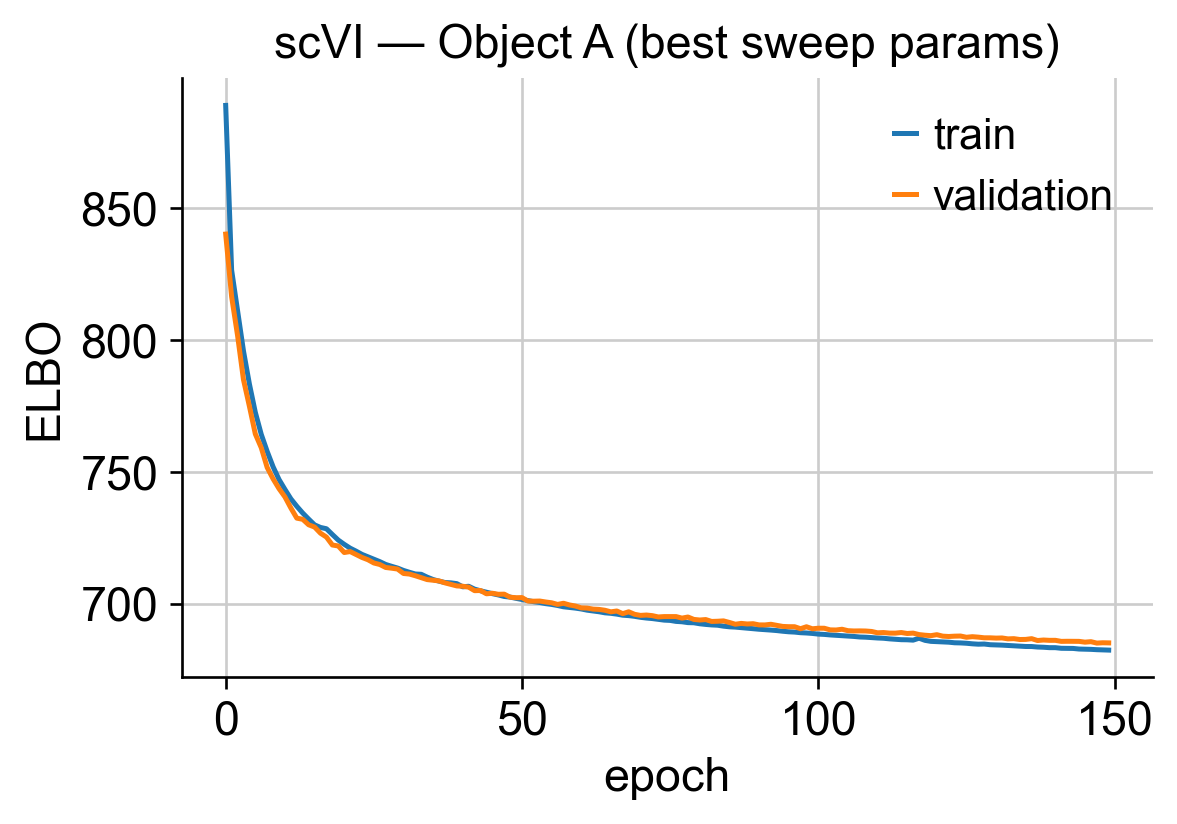

In [79]:
hist_t = model.history['elbo_train'].iloc[:, 0]
hist_v = model.history['elbo_validation'].iloc[:, 0]
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(hist_t.index, hist_t.values, label='train')
ax.plot(hist_v.index, hist_v.values, label='validation')
ax.set_xlabel('epoch'); ax.set_ylabel('ELBO')
ax.set_title('scVI — Object A (best sweep params)')
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIG_DIR / 'training_loss.png')
plt.show()


## 4. Latent + UMAP

In [80]:
adata.obsm['X_scvi'] = model.get_latent_representation(give_mean=True)
sc.pp.neighbors(adata, use_rep='X_scvi', n_neighbors=50, metric='minkowski')
sc.tl.umap(adata, random_state=BEST['random_state'], min_dist=0.2, spread=1.0)

/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/neighbors/__init__.py:430: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():


In [81]:
COLOR_KEYS = ['Study_name', 'cell_states', 'age_group', 'lgr5_status', 'gut_region']
QC_KEYS    = ['total_counts', 'n_genes_by_counts']

In [82]:
sc.set_figure_params(dpi=300, figsize=(6, 6))
sc.pl.umap(adata, color=[c for c in COLOR_KEYS if c in adata.obs.columns],
           cmap='magma_r', ncols=3, size=2, frameon=False, show=False)
plt.savefig(FIG_DIR / 'umap_metadata.png', bbox_inches='tight'); plt.close()

sc.pl.umap(adata, color=QC_KEYS, cmap='magma_r', ncols=2, size=2,
           frameon=False, show=False)
plt.savefig(FIG_DIR / 'umap_qc.png', bbox_inches='tight'); plt.close()
print('UMAPs saved \u2192', FIG_DIR)


UMAPs saved → /Users/am336941/Library/CloudStorage/OneDrive-GSK/Desktop/Fetal_stem_cells_analysis/analysis_enhanced/3_integration/3a_human_only/figures/obj_a_scvi


## 5. Persist canonical artefacts

Overwrites:
- `model_scvi_obj_a_scvi/` — scVI model directory (consumed by 3a2 scANVI)
- `integrated_obj_a_scvi.h5ad` — full AnnData with `obsm['X_scvi']` and UMAP


In [83]:
model.save(str(DATA_OUT / 'model_scvi_obj_a_scvi'), overwrite=True)
adata.write_h5ad(DATA_OUT / 'integrated_obj_a_scvi.h5ad', compression='gzip')
print('saved:')
print('  model      \u2192', DATA_OUT / 'model_scvi_obj_a_scvi')
print('  integrated \u2192', DATA_OUT / 'integrated_obj_a_scvi.h5ad')


saved:
  model      → /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/model_scvi_obj_a_scvi
  integrated → /Users/am336941/PhD/data/Fetal_stem_cells_analysis_enhanced/integrated_obj_a_scvi.h5ad


## 6. scIB sanity-check (vs the sweep number)

In [84]:
try:
    from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
    bio = BioConservation(isolated_labels=True, nmi_ari_cluster_labels_kmeans=True,
                          silhouette_label=True, clisi_knn=True)
    batch = BatchCorrection(graph_connectivity=True, ilisi_knn=True,
                            kbet_per_label=False, pcr_comparison=True, bras=True)
    a_lab = adata[adata.obs['cell_states'].astype(str) != 'unknown'].copy()
    bm = Benchmarker(a_lab, batch_key='Study_name', label_key='cell_states',
                     embedding_obsm_keys=['X_scvi'],
                     bio_conservation_metrics=bio, batch_correction_metrics=batch, n_jobs=2)
    bm.benchmark()
    res = bm.get_results(min_max_scale=False, clean_names=True)
    print(res)
    res.to_csv(FIG_DIR / 'scib_metrics.csv')
    plt.figure(figsize=(10, 6))
    bm.plot_results_table(min_max_scale=False, show=False)
    plt.savefig(FIG_DIR / 'scib_benchmark.png', dpi=300, bbox_inches='tight')
    plt.close()
except Exception as e:
    print('scIB skipped:', e)


/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:227: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(adata, mask_var, use_highly_variable)
/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:243: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")
Embeddings:   0%|          | 0/1 [00:00<?, ?it/s]/Users/am336941/uv_envs/lgr5_enhanced/.venv/lib/python3.13/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = p

              Isolated labels        KMeans NMI        KMeans ARI  \
Embedding                                                           
X_scvi               0.563557          0.264208          0.157273   
Metric Type  Bio conservation  Bio conservation  Bio conservation   

             Silhouette label             cLISI              BRAS  \
Embedding                                                           
X_scvi                0.50486          0.911424          0.927911   
Metric Type  Bio conservation  Bio conservation  Batch correction   

                        iLISI Graph connectivity    PCR comparison  \
Embedding                                                            
X_scvi               0.127593           0.780936          0.716052   
Metric Type  Batch correction   Batch correction  Batch correction   

            Batch correction Bio conservation            Total  
Embedding                                                       
X_scvi              0.638123       

<Figure size 3000x1800 with 0 Axes>